# 1. Necessary

In [1]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.style.use('ggplot')

start_date = "2019-01-01"
end_date = "2024-01-01"

#functions
from src.portfolio_stats import calculate_volatility, calculate_max_drawdown, calculate_mean_portfolio_returns, calculate_sharpe_ratio, calculate_cagr, calculate_return_path
from src.optimizations import calculate_negative_sharpe_ratio

#data
data = pd.read_csv("data/prices.csv", index_col="Date", parse_dates=True)

from data_loader import read_rfr
rfr = read_rfr(start_date, end_date)


#checking data
print(rfr)
print(data.head())

[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

0.022721041324881567
                 AAPL        BND        EEM         GLD        JPM  \
Date                                                                 
2019-01-02  37.503723  64.321190  33.319092  121.330002  81.250221   
2019-01-03  33.768082  64.572456  32.714993  122.430000  80.095497   
2019-01-04  35.209625  64.377945  33.770035  121.440002  83.048264   
2019-01-07  35.131233  64.280670  33.846615  121.860001  83.105980   
2019-01-08  35.800961  64.199631  33.974243  121.529999  82.949280   

                   SPY        TSM        XOM  
Date                                          
2019-01-02  224.995316  31.237242  50.001835  
2019-01-03  219.626328  29.389694  49.234131  
2019-01-04  226.982849  29.911461  51.049370  
2019-01-07  228.772552  30.133850  51.314838  
2019-01-08  230.921967  29.885798  51.687946  


# 2. CAPM

## 2.1. Calculating Betas

In [3]:
from scipy.stats import linregress

#we will use SPY as a benchmark
spy_returns = data['SPY'].pct_change().dropna()
betas = {}
r2s = {}

#calculating betas into a dictionary
for col in data.columns:
    if col == 'SPY':
        continue
    asset_returns = data[col].pct_change().dropna()
    slope, intercept, r, p, se = linregress(spy_returns, asset_returns)
    betas[col] = slope
    r2s[col] = r**2


#turning into series for easier access.
betas_series = pd.Series(betas)
r2s_series = pd.Series(r2s)
print(betas_series)

AAPL    1.235198
BND     0.059258
EEM     0.827128
GLD     0.076613
JPM     1.112261
TSM     1.070612
XOM     0.900522
dtype: float64


## 2.2. Calculating Returns

In [4]:
#computing CAPM esitmated return
trading_days = 252
spy_returns_annual = spy_returns.mean() * trading_days
capm_estimated_returns = rfr + betas_series * (spy_returns_annual - rfr)
capm_estimated_returns


AAPL    0.201211
BND     0.031284
EEM     0.142244
GLD     0.033792
JPM     0.183446
TSM     0.177428
XOM     0.152849
dtype: float64

In [5]:
#historic mean/expected asset returns
asset_annual_mean_returns = data.pct_change().mean() * trading_days
asset_annual_mean_returns

AAPL    0.378031
BND     0.012835
EEM     0.053375
GLD     0.102324
JPM     0.189012
SPY     0.167224
TSM     0.298916
XOM     0.182362
dtype: float64

In [6]:
#compare actual with predicted:
capm_comparison_df = pd.DataFrame({'Betas': betas_series,
                                   'CAPM Estimation': capm_estimated_returns,
                                   'Real Mean Returns' : asset_annual_mean_returns,
                                   'Variance Explained by CAPM' : r2s})

capm_comparison_df = capm_comparison_df.dropna(axis=0) # dropping SPY - which has NaN because it's the benchmark

#CONCLUSION: capm estimated returns edviate significantly from actual mean returns for the majority of assets.
#the 1 factor (market exposure) that capm uses to estimate returns doesn't explain nearly enough variance in the markets.

## 2.3. Comparing Actual vs Predicted (+ plotting)

In [8]:
capm_comparison_df

,Betas,CAPM Estimation,Real Mean Returns,Variance Explained by CAPM
AAPL,1.235198,0.201211,0.378031,0.647281
BND,0.059258,0.031284,0.012835,0.033927
EEM,0.827128,0.142244,0.053375,0.602528
GLD,0.076613,0.033792,0.102324,0.011597
JPM,1.112261,0.183446,0.189012,0.535989
TSM,1.070612,0.177428,0.298916,0.397942
XOM,0.900522,0.152849,0.182362,0.304277


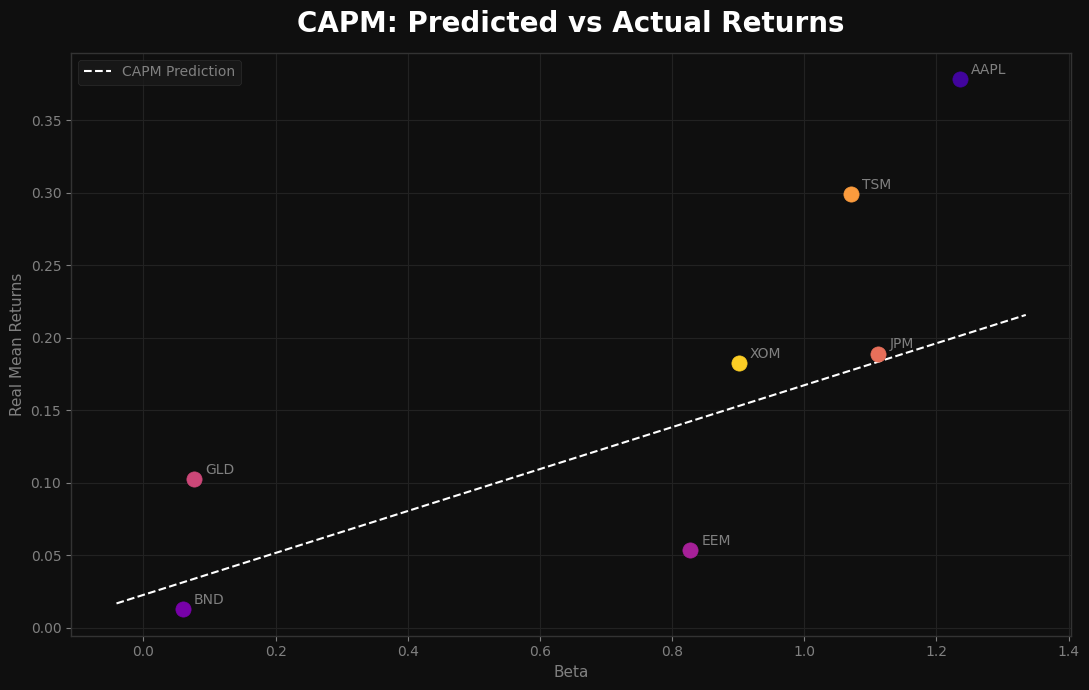

In [9]:
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

# CAPM line
x_line = np.linspace(capm_comparison_df['Betas'].min() - 0.1, capm_comparison_df['Betas'].max() + 0.1, 100)
y_line = rfr + x_line * (spy_returns_annual - rfr)
ax.plot(x_line, y_line, color='white', linewidth=1.5, linestyle='--', label='CAPM Prediction', zorder=2)

# one scatter point per asset
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(capm_comparison_df)))
for i, (asset, row) in enumerate(capm_comparison_df.iterrows()):
    ax.scatter(row['Betas'], row['Real Mean Returns'], color=colors[i], s=120, zorder=3)
    ax.annotate(asset, (row['Betas'], row['Real Mean Returns']),
                textcoords="offset points", xytext=(8, 4), color='grey', fontsize=10)

# formatting
ax.set_xlabel('Beta', color='grey', fontsize=11)
ax.set_ylabel('Real Mean Returns', color='grey', fontsize=11)
ax.set_title('CAPM: Predicted vs Actual Returns', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

In [10]:
# if returns were 100% accurate, the asset returns would sit on the capm line
# this shows that the 1 factor doesnt explain nearly enough variance to be useful.

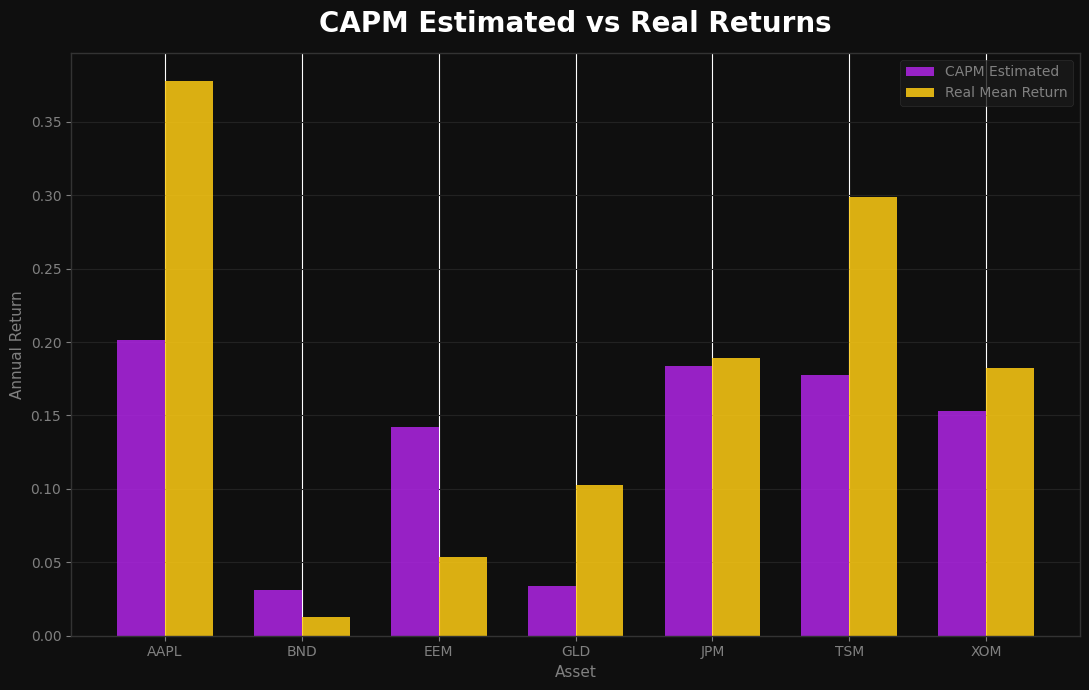

In [11]:
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

x = np.arange(len(capm_comparison_df))
width = 0.35

ax.bar(x - width/2, capm_comparison_df['CAPM Estimation'], width, 
       label='CAPM Estimated', color="#b025e6", alpha=0.85)
ax.bar(x + width/2, capm_comparison_df['Real Mean Returns'], width, 
       label='Real Mean Return', color="#ffcc13", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(capm_comparison_df.index, color='grey', fontsize=10)
ax.set_xlabel('Asset', color='grey', fontsize=11)
ax.set_ylabel('Annual Return', color='grey', fontsize=11)
ax.set_title('CAPM Estimated vs Real Returns', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8, axis='y')
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

# Day 5 - Out of Sample Performance Test

In [106]:
#training on 3 years, then checking performance on latter 2.

In [107]:
train_start_date = '2019-01-03'
train_end_date = '2021-12-31'
test_start_date = '2022-01-01'
test_end_date = '2023-12-31'

train_data = data.loc[train_start_date : train_end_date]
test_data = data.loc[test_start_date : test_end_date]

In [108]:
train_data

,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
Date,,,,,,,,
2019-01-03,33.768074,64.572441,32.714996,122.430000,80.095505,219.626312,29.389702,49.234142
2019-01-04,35.209614,64.377930,33.770046,121.440002,83.048256,226.982864,29.911455,51.049374
2019-01-07,35.131245,64.280670,33.846619,121.860001,83.105995,228.772552,30.133850,51.314842
2019-01-08,35.800957,64.199623,33.974255,121.529999,82.949287,230.921951,29.885803,51.687935
2019-01-09,36.408909,64.288780,34.578339,122.309998,82.809074,232.001190,30.458881,51.960583
...,...,...,...,...,...,...,...,...
2021-12-27,176.459717,73.956093,44.365379,169.369995,141.756668,451.449524,114.628281,53.338226
2021-12-28,175.442017,73.947365,44.220329,168.639999,142.186859,451.080627,114.030380,53.165863
2021-12-29,175.530106,73.703377,44.020901,168.589996,142.115173,451.657562,113.423134,52.700474


In [109]:
init_guess

array([0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125])

In [111]:
from data_loader import read_rfr
rfr = read_rfr(start_date, end_date)

[*********************100%***********************]  1 of 1 completed


In [112]:
rfr

0.022721041324881567

In [113]:
#fitting tangency portfolio on train data
rfr = read_rfr(train_start_date, train_end_date)
print('RFR Train:',rfr)

constraints_train = ({
    'type':'eq',
    'fun':lambda weights: np.sum(weights) - 1
    })

n = len(train_data.columns)
bounds_train = [(0,1)] * n

tangency_portfolio_train = minimize(calculate_negative_sharpe_ratio, init_guess, args=(train_data,), constraints=constraints_train, bounds=bounds_train)

[*********************100%***********************]  1 of 1 completed

RFR Train: 0.014843827791561355


Text(0.5, 1.0, 'Tangency Portfolio Weights (Stress Test)')

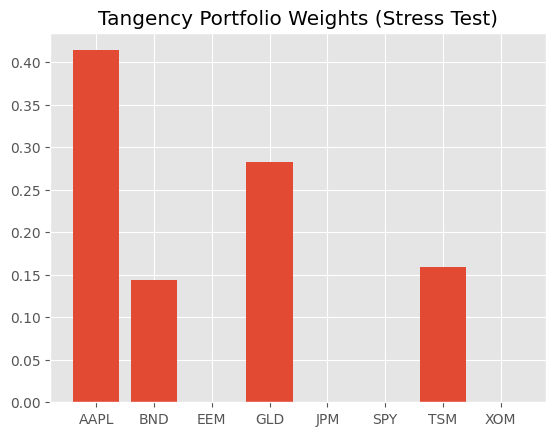

In [114]:
plt.bar(train_data.columns, tangency_portfolio_train.x)
plt.title('Tangency Portfolio Weights (Stress Test)')

In [115]:
#reporting train performance:
print('Train Data Performance:')
tangency_port_train_volatility = calculate_volatility(tangency_portfolio_train.x, train_data)
tangency_port_train_mean_return = calculate_mean_portfolio_returns(tangency_portfolio_train.x, train_data)
tangency_port_train_cagr = calculate_cagr(tangency_portfolio_train.x, train_data)
tangency_port_train_sharpe = calculate_sharpe_ratio(tangency_portfolio_train.x, train_data)

print('Train Tangency Portfolio Volatility:', tangency_port_train_volatility)
print('Train Tangency Portfolio Mean Returns:', tangency_port_train_mean_return)
print('Train Tangency Portfolio CAGR:', tangency_port_train_cagr)
print('Train Tangency Portfolio Sharpe Ratio:',tangency_port_train_sharpe)

#comparing to test performance:
print('Test Data Performance:')
tangency_port_test_volatility = calculate_volatility(tangency_portfolio_train.x, test_data)
tangency_port_test_mean_return = calculate_mean_portfolio_returns(tangency_portfolio_train.x, test_data)
tangency_port_test_cagr = calculate_cagr(tangency_portfolio_train.x, test_data)
tangency_port_test_sharpe = calculate_sharpe_ratio(tangency_portfolio_train.x, test_data)

print('Test Tangency Portfolio Volatility:', tangency_port_test_volatility)
print('Test Tangency Portfolio Mean Returns:', tangency_port_test_mean_return)
print('Test Tangency Portfolio CAGR:', tangency_port_test_cagr)
print('Test Tangency Portfolio Sharpe Ratio:',tangency_port_test_sharpe)

Train Data Performance:
Train Tangency Portfolio Volatility: 0.1888171905168201
Train Tangency Portfolio Mean Returns: 0.3730468718628638
Train Tangency Portfolio CAGR: 0.42546140766223783
Train Tangency Portfolio Sharpe Ratio: 1.8553704224657168
Test Data Performance:
Test Tangency Portfolio Volatility: 0.17238220498286613
Test Tangency Portfolio Mean Returns: 0.04329866398884151
Test Tangency Portfolio CAGR: 0.028847539417271584
Test Tangency Portfolio Sharpe Ratio: 0.11937208174129872


In [116]:
#plotting the return paths throughout the test and train period for the portfolio
stress_test_return_path = calculate_return_path(tangency_portfolio_train.x, data)

#converting into series for earlier plotting
stress_test_return_path = pd.Series(stress_test_return_path, index=data.index)
stress_test_return_path.dropna()

Date
2019-01-03    0.952431
2019-01-04    0.969380
2019-01-07    0.970373
2019-01-08    0.975843
2019-01-09    0.987656
                ...   
2023-12-22    2.964509
2023-12-26    2.973770
2023-12-27    2.981865
2023-12-28    2.978898
2023-12-29    2.966723
Length: 1257, dtype: float64

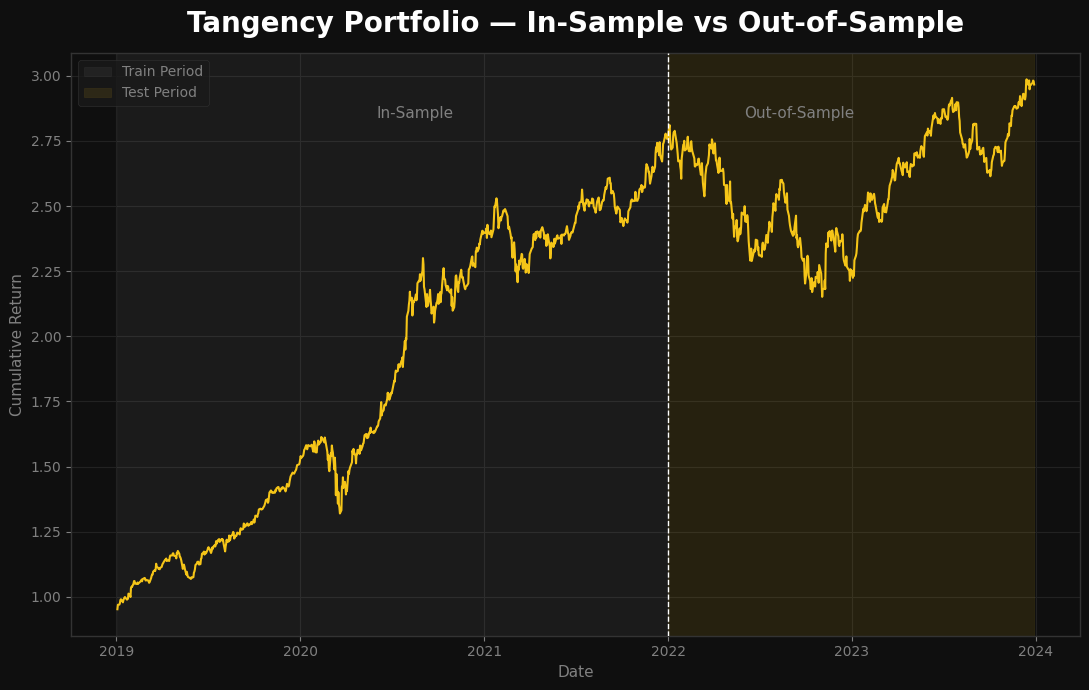

In [117]:
#return path across 5 years with the weights fitted on the first three.

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

# plot the return path
ax.plot(stress_test_return_path.index, stress_test_return_path.values,
        color='#f5c518', linewidth=1.5, zorder=2)

# vertical line separating train and test
split_date = '2022-01-01'
ax.axvline(x=pd.Timestamp(split_date), color='white', linewidth=1, linestyle='--', zorder=3)

# shade the two regions
ax.axvspan(stress_test_return_path.index[0], pd.Timestamp(split_date),
           alpha=0.05, color='white', label='Train Period')
ax.axvspan(pd.Timestamp(split_date), stress_test_return_path.index[-1],
           alpha=0.1, color='#f5c518', label='Test Period')

# label the two regions
ax.text(pd.Timestamp('2020-06-01'), stress_test_return_path.max() * 0.95,
        'In-Sample', color='grey', fontsize=11)
ax.text(pd.Timestamp('2022-06-01'), stress_test_return_path.max() * 0.95,
        'Out-of-Sample', color='grey', fontsize=11)

# formatting
ax.set_xlabel('Date', color='grey', fontsize=11)
ax.set_ylabel('Cumulative Return', color='grey', fontsize=11)
ax.set_title('Tangency Portfolio — In-Sample vs Out-of-Sample', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

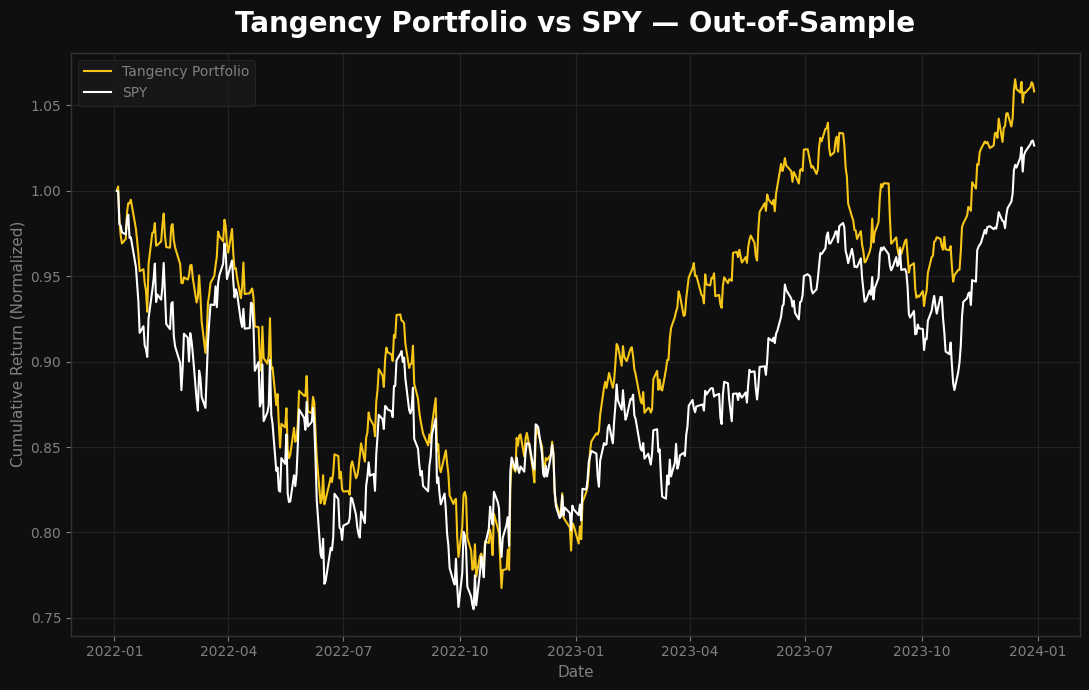

In [125]:
#comparing portfolio returns on test data with spy returns in the same period:

# isolate test period
test_start = '2022-01-01'
portfolio_test = stress_test_return_path[test_start:]

# spy return path over same period
spy_weights = np.array([1.0 if c == 'SPY' else 0.0 for c in data.columns])
spy_return_path = pd.Series(calculate_return_path(spy_weights, data), index=data.index)
spy_test = spy_return_path[test_start:]

# normalize both to start at 1 on the first day of test period
portfolio_test = portfolio_test / portfolio_test.iloc[0]
spy_test = spy_test / spy_test.iloc[0]

# plot
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

ax.plot(portfolio_test.index, portfolio_test.values, color='#f5c518', linewidth=1.5, label='Tangency Portfolio')
ax.plot(spy_test.index, spy_test.values, color='white', linewidth=1.5, label='SPY')

ax.set_xlabel('Date', color='grey', fontsize=11)
ax.set_ylabel('Cumulative Return (Normalized)', color='grey', fontsize=11)
ax.set_title('Tangency Portfolio vs SPY — Out-of-Sample', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

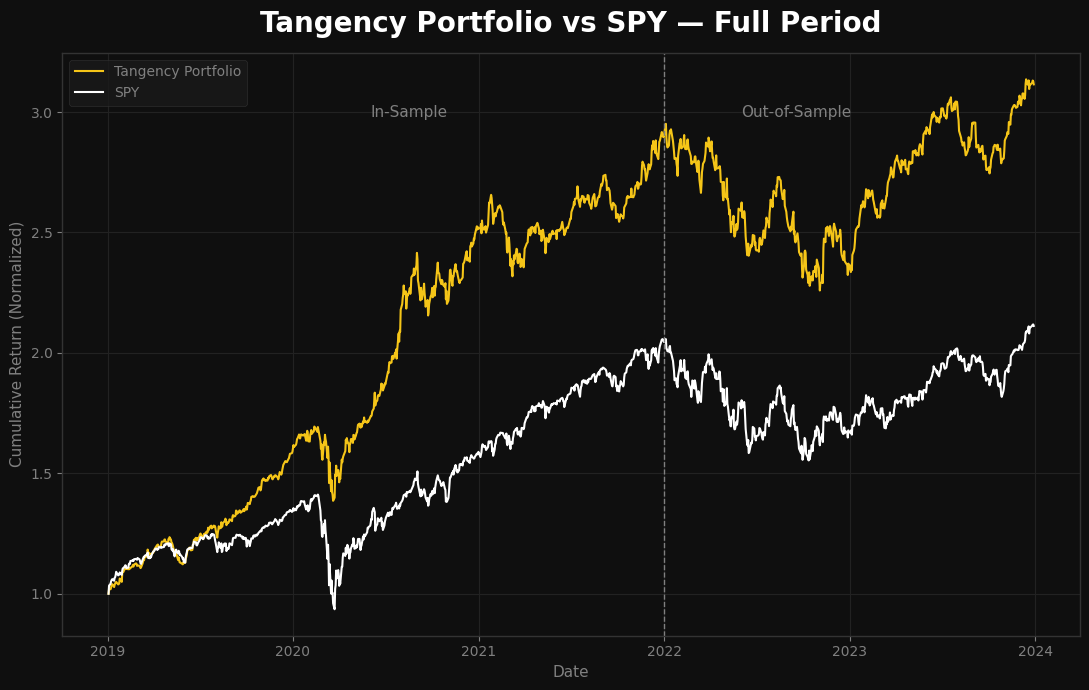

In [119]:
# normalize both to start at 1 on the first day
portfolio_full = stress_test_return_path.dropna() / stress_test_return_path.dropna().iloc[0]
spy_full = spy_return_path.dropna() / spy_return_path.dropna().iloc[0]

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

ax.plot(portfolio_full.index, portfolio_full.values, color='#f5c518', linewidth=1.5, label='Tangency Portfolio')
ax.plot(spy_full.index, spy_full.values, color='white', linewidth=1.5, label='SPY')

# train/test split line
ax.axvline(x=pd.Timestamp('2022-01-01'), color='grey', linewidth=1, linestyle='--')
ax.text(pd.Timestamp('2020-06-01'), portfolio_full.max() * 0.95, 'In-Sample', color='grey', fontsize=11)
ax.text(pd.Timestamp('2022-06-01'), portfolio_full.max() * 0.95, 'Out-of-Sample', color='grey', fontsize=11)

ax.set_xlabel('Date', color='grey', fontsize=11)
ax.set_ylabel('Cumulative Return (Normalized)', color='grey', fontsize=11)
ax.set_title('Tangency Portfolio vs SPY — Full Period', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

In [120]:
# conclusion: the dominance of the optimal portfolio over the
# benchmark SPY basically vanished in the out-of-sample period, suggesting overfitting.

In [121]:
#the poorer performance in the test period could be due to a broader worse period in the market however.
# for an accurate assesment, we must compare to an equal weight portfolio baseline.


In [122]:
stress_test_return_path

Date
2019-01-02         NaN
2019-01-03    0.952431
2019-01-04    0.969380
2019-01-07    0.970373
2019-01-08    0.975843
                ...   
2023-12-22    2.964509
2023-12-26    2.973770
2023-12-27    2.981865
2023-12-28    2.978898
2023-12-29    2.966723
Length: 1258, dtype: float64

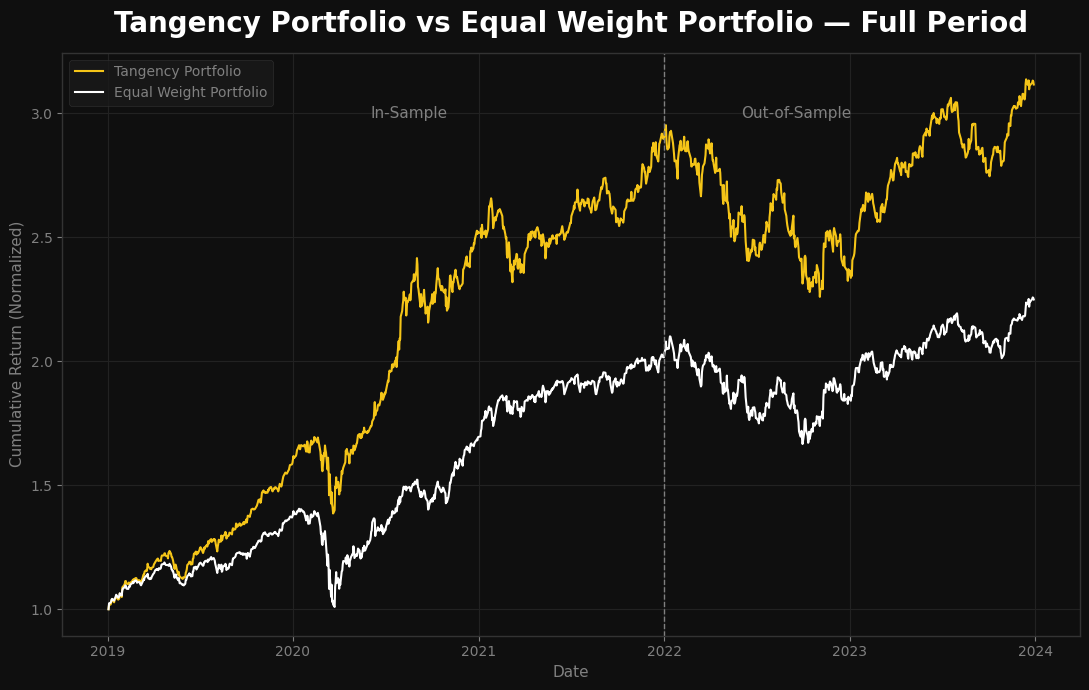

In [123]:
# normalize both to start at 1 on the first day
portfolio_full = stress_test_return_path.dropna() / stress_test_return_path.dropna().iloc[0]
eq_return_path = pd.Series(eq_return_path, stress_test_return_path.index)
eq_full = eq_return_path.dropna() / eq_return_path.dropna().iloc[0]

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

ax.plot(portfolio_full.index, portfolio_full.values, color='#f5c518', linewidth=1.5, label='Tangency Portfolio')
ax.plot(eq_full.index, eq_full.values, color='white', linewidth=1.5, label='Equal Weight Portfolio')

# train/test split line
ax.axvline(x=pd.Timestamp('2022-01-01'), color='grey', linewidth=1, linestyle='--')
ax.text(pd.Timestamp('2020-06-01'), portfolio_full.max() * 0.95, 'In-Sample', color='grey', fontsize=11)
ax.text(pd.Timestamp('2022-06-01'), portfolio_full.max() * 0.95, 'Out-of-Sample', color='grey', fontsize=11)

ax.set_xlabel('Date', color='grey', fontsize=11)
ax.set_ylabel('Cumulative Return (Normalized)', color='grey', fontsize=11)
ax.set_title('Tangency Portfolio vs Equal Weight Portfolio — Full Period', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

In [124]:
#calculating out of sample return of both:
oos_start = '2022-01-01'

portfolio_oos = portfolio_full[portfolio_full.index >= oos_start]
eq_oos = eq_full[eq_full.index >= oos_start]

tangency_total_return = (portfolio_oos.iloc[-1] / portfolio_oos.iloc[0] - 1) * 100
eq_total_return = (eq_oos.iloc[-1] / eq_oos.iloc[0] - 1) * 100

print(f"Tangency Portfolio OOS Total Return: {tangency_total_return:.2f}%")
print(f"Equal Weight Portfolio OOS Total Return: {eq_total_return:.2f}%")

Tangency Portfolio OOS Total Return: 5.82%
Equal Weight Portfolio OOS Total Return: 9.54%


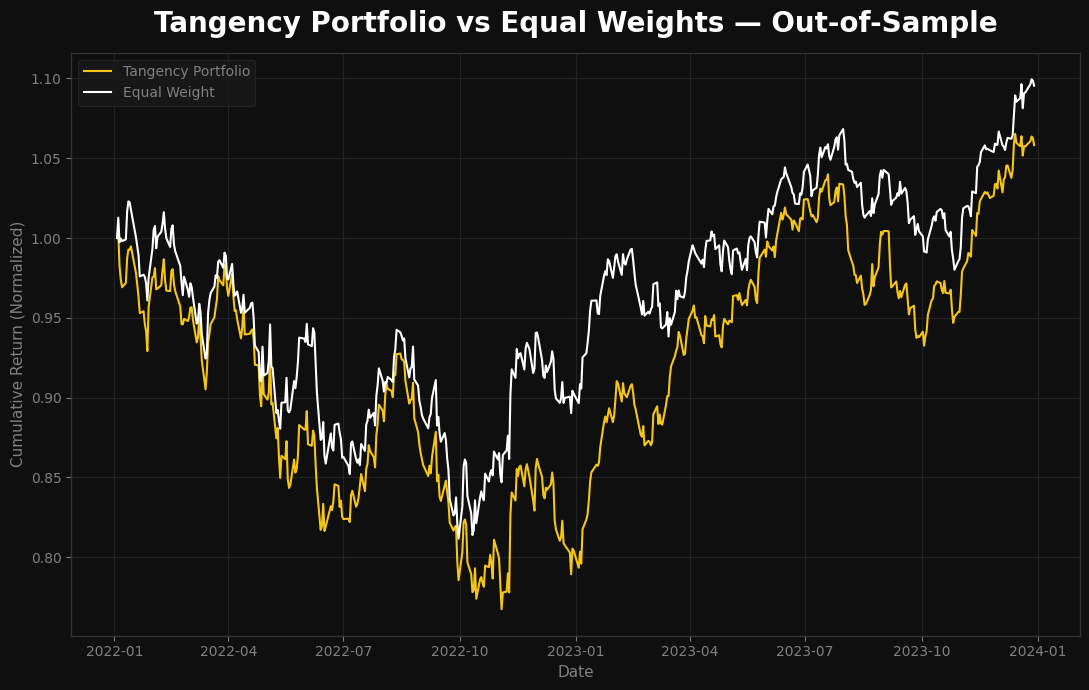

In [126]:
#comparing portfolio returns on test data with spy returns in the same period:

# isolate test period
test_start = '2022-01-01'
portfolio_test = stress_test_return_path[test_start:]

# spy return path over same period
equal_weights = np.ones(len(data.columns)) / len(data.columns)
eq_return_path = pd.Series(calculate_return_path(equal_weights, data), index=data.index)
eq_test = eq_return_path[test_start:]

# normalize both to start at 1 on the first day of test period
portfolio_test = portfolio_test / portfolio_test.iloc[0]
eq_test = eq_test / eq_test.iloc[0]

# plot
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

ax.plot(portfolio_test.index, portfolio_test.values, color='#f5c518', linewidth=1.5, label='Tangency Portfolio')
ax.plot(eq_test.index, eq_test.values, color='white', linewidth=1.5, label='Equal Weight')

ax.set_xlabel('Date', color='grey', fontsize=11)
ax.set_ylabel('Cumulative Return (Normalized)', color='grey', fontsize=11)
ax.set_title('Tangency Portfolio vs Equal Weights — Out-of-Sample', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()